In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os 
pd.set_option('display.width', None)
pd.set_option('display.max_rows', None)

os.chdir('/Users/felixdiederichs/PycharmProjects/Data_Analysis/.venv/Analyse/Heart/')

# Prepare data
Statistical tests and distance calculations: \
Value > 0.5 -> '3' \
Value < 0.5 && Value > 0 -> '2' \
Value == 0 -> '1' 

In [3]:
df = pd.read_csv('heart_resemblance_2.csv', sep='\t')
df_numerical_tests = pd.read_excel('Report_heart_resemblance_numerical_tests.xlsx')
df_distances = pd.read_excel('Report_heart_resemblance_distances.xlsx')

In [4]:


def evaluate_ura_columns(df, input_column_name, output_column_name):
    df[output_column_name] = 1
    df.loc[df[input_column_name] > 0.5, output_column_name] = 3
    df.loc[(df[input_column_name] <= 0.5) & (df[input_column_name] > 0), output_column_name] = 2
    
evaluate_ura_columns(df, 'Numerical tests', 'Evaluation numerical tests')
evaluate_ura_columns(df, 'Categorical tests', 'Evaluation categorical tests')
evaluate_ura_columns(df, 'Distances ', 'Evaluation distances')

def evaluate_mra_columns(df, input_column_name, output_column_name):
    df[output_column_name] = 1
    df.loc[df[input_column_name] > 0.6, output_column_name] = 3
    df.loc[(df[input_column_name] <= 0.6) & (df[input_column_name] >= 0.4), output_column_name] = 2

evaluate_mra_columns(df, 'Numerical correlations ', 'Evaluation numerical correlations')
evaluate_mra_columns(df, 'Categorical correlations', 'Evaluation categorical correlations')

df['Mean DLA'] = df[['Average Precision', 'Average Recall ', 'Average Accuracy ', 'Average F1']].mean(axis=1)

def evaluate_dla_columns(df, input_column_name, output_column_name):
    # Use boolean masks directly for .loc indexing
    mask_low = df[input_column_name] <= 0.6
    mask_mid = (df[input_column_name] > 0.6) & (df[input_column_name] < 0.8)
    mask_high = df[input_column_name] >= 0.8

    df.loc[mask_low, output_column_name] = int(3)
    df.loc[mask_mid, output_column_name] = int(2)
    df.loc[mask_high, output_column_name] = int(1)

evaluate_dla_columns(df, 'Mean DLA', 'DLA Score')

weighted_evaluations = df[['Evaluation numerical tests', 'Evaluation categorical tests', 'Evaluation distances']] * 0.3
df['URA Score'] = weighted_evaluations.sum(axis=1) 

weighted_evaluations = df[['Evaluation numerical correlations', 'Evaluation categorical correlations']] * 0.5
df['MRA Score'] = weighted_evaluations.sum(axis=1)

df['Resemblance score'] = (df['URA Score'] * 0.4) + (df['MRA Score'] * 0.4) + (df['DLA Score'] * 0.2)

df
    

,Model,Epochs,Lambda,Numerical tests,Categorical tests,Distances,Numerical correlations,Categorical correlations,Average Precision,Average Recall,...,Evaluation numerical tests,Evaluation categorical tests,Evaluation distances,Evaluation numerical correlations,Evaluation categorical correlations,Mean DLA,DLA Score,URA Score,MRA Score,Resemblance score
0,tabfairgan,50,0.2,0.090909,0.025974,0.866667,0.418182,0.255455,0.716502,0.714638,...,2,2,3,2,1,0.714825,2.0,2.1,1.5,1.84
1,tabfairgan,50,0.4,0.175758,0.051948,0.872727,0.390909,0.317273,0.721422,0.720013,...,2,2,3,1,1,0.720248,2.0,2.1,1.0,1.64
2,tabfairgan,50,0.6,0.133333,0.012987,0.860606,0.463636,0.299091,0.718680,0.716485,...,2,2,3,2,1,0.716842,2.0,2.1,1.5,1.84
3,tabfairgan,50,0.8,0.175758,0.038961,0.866667,0.381818,0.248182,0.704002,0.702004,...,2,2,3,1,1,0.702322,2.0,2.1,1.0,1.64
4,tabfairgan,50,1.0,0.200000,0.051948,0.878788,0.390909,0.298182,0.708209,0.706016,...,2,2,3,1,1,0.706313,2.0,2.1,1.0,1.64
5,tabfairgan,50,1.5,0.200000,0.012987,0.878788,0.345455,0.294545,0.716733,0.714296,...,2,2,3,1,1,0.714671,2.0,2.1,1.0,1.64
6,tabfairgan,50,2.0,0.121212,0.038961,0.884848,0.400000,0.260000,0.704753,0.702507,...,2,2,3,2,1,0.702735,2.0,2.1,1.5,1.84
7,tabfairgan,50,5.0,0.175758,0.064935,0.890909,0.336364,0.250909,0.709231,0.707425,...,2,2,3,1,1,0.707624,2.0,2.1,1.0,1.64
8,tabfairgan,100,0.2,0.145455,0.000000,0.836364,0.400000,0.338182,0.724016,0.719667,...,2,1,3,2,1,0.720439,2.0,1.8,1.5,1.72
9,tabfairgan,100,0.4,0.230303,0.051948,0.836364,0.336364,0.333636,0.708156,0.703464,...,2,2,3,1,1,0.704243,2.0,2.1,1.0,1.64


# Overall Resemblance Score

,count,mean,std,min,25%,50%,75%,max
Model,,,,,,,,
ctgan,6.0,1.720000,0.138564,1.52,1.64,1.74,1.84,1.84
distcorrgan,48.0,1.751667,0.106618,1.64,1.64,1.84,1.84,2.04
multifairgan,48.0,1.649167,0.065097,1.52,1.64,1.64,1.64,1.84
tabfairgan,48.0,1.904167,0.192230,1.64,1.70,1.94,2.04,2.24
tvae,3.0,2.040000,0.000000,2.04,2.04,2.04,2.04,2.04


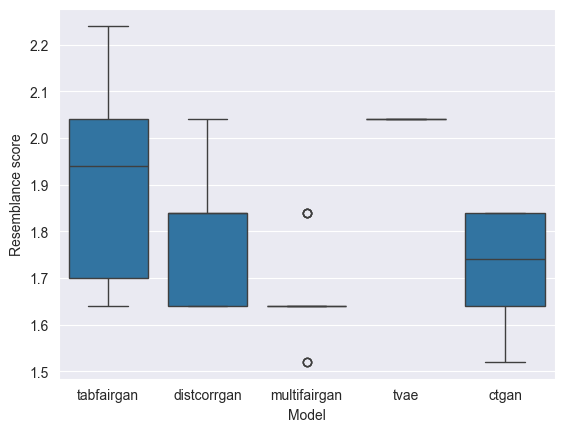

In [5]:
sns.boxplot(x='Model', y='Resemblance score', data=df)

averages = df.groupby('Model')
averages['Resemblance score'].describe()

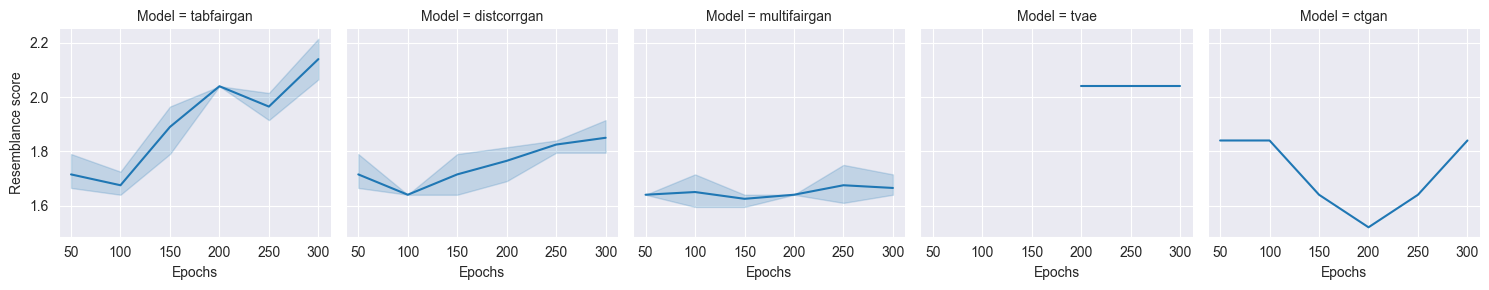

In [6]:
group_overall_score = df.groupby(['Model', 'Epochs'])['Resemblance score'].mean().reset_index()

fg = sns.FacetGrid(data=df, col='Model')
fg.map(sns.lineplot, 'Epochs', 'Resemblance score', data=df)

# Univariate Resemblance Score

<Axes: xlabel='Model', ylabel='URA Score'>

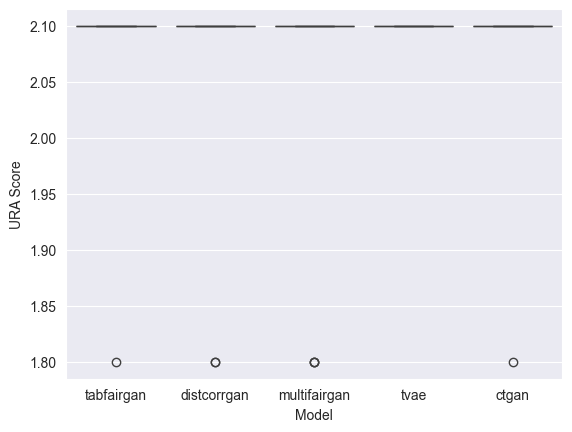

In [7]:
sns.boxplot(x='Model', y='URA Score', data=df)

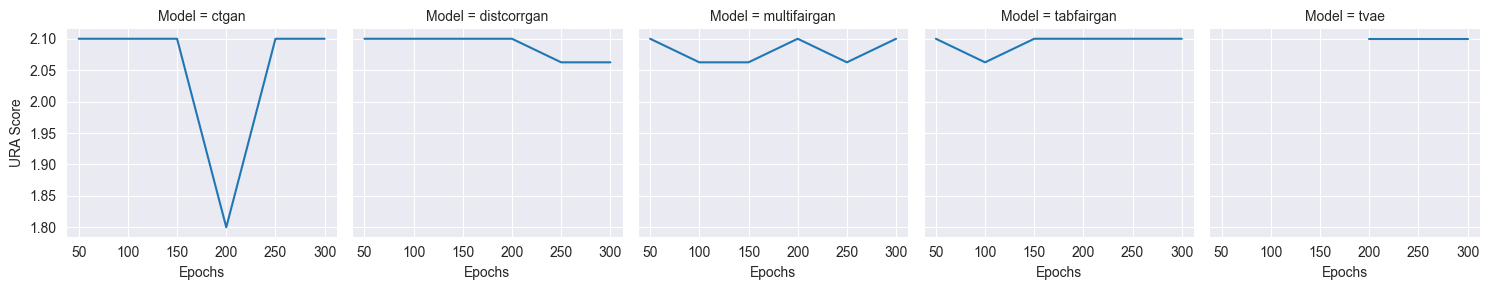

In [8]:
group_overall_score = df.groupby(['Model', 'Epochs'])['URA Score'].mean().reset_index()

fg = sns.FacetGrid(data=group_overall_score, col='Model')
fg.map(sns.lineplot, 'Epochs', 'URA Score')

## Statistical tests

<Axes: xlabel='Model', ylabel='Numerical tests'>

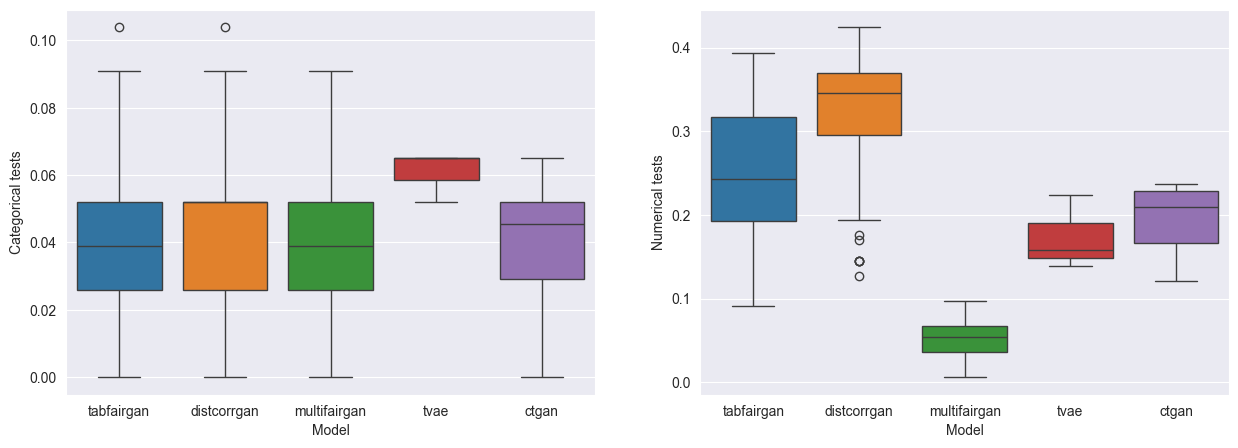

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(x='Model', y='Categorical tests', hue='Model', data = df, ax = axes[0])
sns.boxplot(x='Model', y='Numerical tests', hue='Model', data=df, ax = axes[1])

In [10]:
df.groupby(['Model'])['Numerical tests'].median().reset_index()

,Model,Numerical tests
0,ctgan,0.209091
1,distcorrgan,0.345455
2,multifairgan,0.054545
3,tabfairgan,0.242424
4,tvae,0.157576


In [11]:
df_numerical_tests

,t-test,Mann-Whitney,Kolmogorov-Smirnov,Loop,Model,Epochs,Lambda,Variable
0,5.509319e-12,2.871211e-12,5.996639e-62,1,tabfairgan,50,0.2,Age
1,1.913824e-33,2.664019e-08,3.433578e-65,1,tabfairgan,50,0.2,RestingBP
2,1.533427e-07,7.127033e-01,1.795123e-39,1,tabfairgan,50,0.2,Cholesterol
3,4.247447e-51,1.401541e-51,3.058986e-124,1,tabfairgan,50,0.2,MaxHR
4,2.358164e-69,5.355415e-94,1.356966e-61,1,tabfairgan,50,0.2,Oldpeak
5,3.201055e-98,1.448090e-75,2.057654e-53,1,tabfairgan,50,0.4,Age
6,0.000000e+00,2.784777e-238,3.981935e-242,1,tabfairgan,50,0.4,RestingBP
7,1.536606e-45,2.151458e-74,1.144399e-104,1,tabfairgan,50,0.4,Cholesterol
8,1.456511e-23,1.480238e-19,5.351778e-48,1,tabfairgan,50,0.4,MaxHR
9,4.757299e-86,4.960431e-50,7.748542e-60,1,tabfairgan,50,0.4,Oldpeak


In [12]:
pd.set_option('display.float_format', '{:,.4f}'.format)
l = df_numerical_tests.groupby(['Model', 'Epochs', 'Variable']).mean(numeric_only=True)

l

t-test  Mann-Whitney  Kolmogorov-Smirnov  \
Model        Epochs Variable                                                
ctgan        50     Age          0.1622        0.1196              0.0002   
                    Cholesterol  0.0428        0.0968              0.0000   
                    MaxHR        0.0781        0.1279              0.0000   
                    Oldpeak      0.0000        0.0000              0.0000   
                    RestingBP    0.0863        0.1426              0.0000   
             100    Age          0.0720        0.0844              0.0006   
                    Cholesterol  0.0541        0.0961              0.0000   
                    MaxHR        0.0443        0.0085              0.0000   
                    Oldpeak      0.1358        0.0004              0.0000   
                    RestingBP    0.2275        0.1553              0.0002   
             150    Age          0.1049        0.1261              0.0000   
                    Cholesterol  0.2396        0.2170              0.0000   
                    MaxHR        0.0248        0.0240              0.0000   
                    Oldpeak      0.2323        0.0347              0.0001   
                    RestingBP    0.2939        0.2980              0.0016   
             200    Age          0.1007        0.0704              0.0094   
                    Cholesterol  0.3845        0.1825              0.0000   
                    MaxHR        0.0683        0.0763              0.0003   
                    Oldpeak      0.0240        0.0185              0.0000   
                    RestingBP    0.1084        0.1437              0.0020   
             250    Age          0.0339        0.0234              0.0004   
                    Cholesterol  0.1242        0.1271              0.0000   
                    MaxHR        0.2010        0.3723              0.0001   
                    Oldpeak      0.2336        0.0296              0.0000   
                    RestingBP    0.3846        0.2884              0.0014   
             300    Age          0.0163        0.0168              0.0000   
                    Cholesterol  0.2143        0.1135              0.0001   
                    MaxHR        0.3429        0.2550              0.0000   
                    Oldpeak      0.1751        0.0000              0.0000   
                    RestingBP    0.1187        0.1524              0.0003   
distcorrgan  50     Age          0.1394        0.1324              0.0007   
                    Cholesterol  0.0612        0.1086              0.0000   
                    MaxHR        0.0851        0.1087              0.0008   
                    Oldpeak      0.0501        0.0091              0.0000   
                    RestingBP    0.1291        0.1452              0.0012   
             100    Age          0.3024        0.3500              0.0035   
                    Cholesterol  0.0543        0.3034              0.0027   
                    MaxHR        0.2470        0.2835              0.0030   
                    Oldpeak      0.1132        0.0000              0.0000   
                    RestingBP    0.2877        0.3590              0.0020   
             150    Age          0.2962        0.4560              0.0052   
                    Cholesterol  0.0782        0.2975              0.0059   
                    MaxHR        0.3737        0.4245              0.0073   
                    Oldpeak      0.1109        0.0007              0.0000   
                    RestingBP    0.3246        0.3982              0.0070   
             200    Age          0.3224        0.4445              0.0085   
                    Cholesterol  0.1802        0.1494              0.0029   
                    MaxHR        0.3583        0.2825              0.0095   
                    Oldpeak      0.1730        0.0001              0.0000   
                    RestingBP    0.2258        0.3516              0.0061   
             250    Age      

In [14]:
df_distances    

,Cosine distance,JS distance,Wass distance,Loop,Model,Epochs,Lambda,Variable
0,0.3187,0.0743,0.2209,1,tabfairgan,50,0.2000,Age
1,0.2480,0.0730,0.3096,1,tabfairgan,50,0.2000,RestingBP
2,0.3826,0.0761,0.2467,1,tabfairgan,50,0.2000,Cholesterol
3,0.4036,0.0717,0.3029,1,tabfairgan,50,0.2000,MaxHR
4,0.3546,0.0364,0.2094,1,tabfairgan,50,0.2000,Oldpeak
5,0.1008,0.0670,0.2184,1,tabfairgan,50,0.4000,Age
6,0.4911,0.0350,0.5060,1,tabfairgan,50,0.4000,RestingBP
7,0.5798,0.0465,0.2253,1,tabfairgan,50,0.4000,Cholesterol
8,0.2875,0.0662,0.1937,1,tabfairgan,50,0.4000,MaxHR
9,0.1678,0.0760,0.2420,1,tabfairgan,50,0.4000,Oldpeak


In [19]:
df_distances.groupby(['Model', 'Epochs', 'Variable']).mean(numeric_only=True)

Cosine distance  JS distance  Wass distance  \
Model        Epochs Variable                                                   
ctgan        50     Age                   0.1508       0.0573         0.0659   
                    Cholesterol           0.2084       0.0303         0.0702   
                    MaxHR                 0.1200       0.0571         0.0925   
                    Oldpeak               0.1121       0.0279         0.0830   
                    RestingBP             0.0786       0.0352         0.2458   
             100    Age                   0.1480       0.0573         0.0668   
                    Cholesterol           0.2586       0.0316         0.0616   
                    MaxHR                 0.1581       0.0560         0.0835   
                    Oldpeak               0.1590       0.0333         0.0947   
                    RestingBP             0.0807       0.0374         0.2303   
             150    Age                   0.1541       0.0596         0.0746   
                    Cholesterol           0.2419       0.0300         0.0435   
                    MaxHR                 0.1286       0.0572         0.0702   
                    Oldpeak               0.1535       0.0329         0.0862   
                    RestingBP             0.0895       0.0383         0.2424   
             200    Age                   0.1539       0.0577         0.0667   
                    Cholesterol           0.2588       0.0313         0.0505   
                    MaxHR                 0.1245       0.0571         0.0648   
                    Oldpeak               0.1423       0.0300         0.0973   
                    RestingBP             0.0829       0.0378         0.2332   
             250    Age                   0.1534       0.0587         0.0672   
                    Cholesterol           0.2446       0.0343         0.0615   
                    MaxHR                 0.1412       0.0572         0.0636   
                    Oldpeak               0.1513       0.0330         0.0851   
                    RestingBP             0.0815       0.0358         0.2451   
             300    Age                   0.1581       0.0607         0.0735   
                    Cholesterol           0.2426       0.0320         0.0520   
                    MaxHR                 0.1398       0.0587         0.0694   
                    Oldpeak               0.2167       0.0323         0.1341   
                    RestingBP             0.0845       0.0381         0.2319   
distcorrgan  50     Age                   0.1166       0.0453         0.0727   
                    Cholesterol           0.2267       0.0302         0.0688   
                    MaxHR                 0.1104       0.0447         0.0816   
                    Oldpeak               0.1598       0.0311         0.1203   
                    RestingBP             0.0404       0.0314         0.0904   
             100    Age                   0.1138       0.0490         0.0489   
                    Cholesterol           0.2222       0.0353         0.0551   
                    MaxHR                 0.0973       0.0484         0.0529   
                    Oldpeak               0.2007       0.0360         0.1208   
                    RestingBP             0.0428       0.0341         0.0931   
             150    Age                   0.1141       0.0489         0.0480   
                    Cholesterol           0.2412       0.0377         0.0511   
                    MaxHR                 0.0990       0.0489         0.0490   
                    Oldpeak               0.1734       0.0371         0.1035   
                    RestingBP             0.0370       0.0345         0.0599   
             200    Age                   0.1233       0.0514         0.0423   
                    Cholesterol           0.2592       0.0394         0.0519   
                    MaxHR                 0.1153       0.0513         0.0449   
                    Oldpeak      